# Análisis e Interpolación de Perfiles de Viento Vertical

## 1. Descripción del trabajo
Este trabajo se centra en el análisis e interpolación de perfiles de viento vertical, utilizando datos reales de mediciones atmosféricas obtenidas de un SODAR-RASS. 

El objetivo es desarrollar y comparar diferentes métodos de interpolación para caracterizar con precisión la variación de la velocidad del viento con la altura.

## 2. Introducción al SODAR-RASS
El SODAR (Sonic Detection And Ranging) combinado con RASS (Radio Acoustic Sounding System) es un sistema de teledetección atmosférica que permite obtener perfiles verticales de:

- Velocidad y dirección del viento
- Temperatura virtual
- Turbulencia atmosférica

Este instrumento es fundamental para:

- Estudios meteorológicos
- Monitoreo de la capa límite atmosférica
- Evaluación de recursos eólicos
- Estudios de dispersión de contaminantes

## 3. Fundamento Teórico

### 3.1 Perfiles de Viento Vertical

El perfil vertical del viento describe cómo varía la velocidad del viento con la altura sobre el suelo. Los modelos más comunes incluyen:

1. **Ley Potencial**
$$ v(z) = v_{ref} \left(\frac{z}{z_{ref}}\right)^\alpha $$
donde:
- $v(z)$ es la velocidad a la altura $z$
- $v_{ref}$ es la velocidad conocida a la altura de referencia $z_{ref}$
- $\alpha$ es el exponente de cortante (típicamente entre 0.1 y 0.4)

2. **Ley Logarítmica**
$$ v(z) = \frac{u_*}{\kappa} \ln\left(\frac{z-d}{z_0}\right) $$
donde:
- $u_*$ es la velocidad de fricción
- $\kappa$ es la constante de von Kármán (≈ 0.4)
- $z_0$ es la longitud de rugosidad
- $d$ es la altura de desplazamiento




## 4. Datos de perfiles de viento y tempertura reales

En el siguiente enlace se encuentran los datos del instrumento SODAR - RASS con los que debe trabajar 

- [datos sodar-rass](http://200.2.119.39/sodardata/ "datos sodar")

Los datos puede encontrarlos en los archivos con extencion .mnd. (Minisodars Native Data). A modo de  ejemplo se muestra el archivo http://200.2.119.39/sodardata/180218.mnd del día 02-18-2018 


![Ejemplo de datos](./fig/ejemplo_datos.png)

donde la primer fila cantes de cada matriz de datos es la fecha hora y duracion d ela medición

```
2018-01-22 02:00:00 01:00:00 
```
y la cabecera de la matriz representa:   

- z: altura   
- speed: velocidad del viento    
- dir: direccion del viento
- W: viento vertical 
- sigW: variación del viento vertical 
- T: temperatura virtual 
- bck: back scater
- error: error  

los datos con 999.99 o 99.99 son datos nulos por los que deben ser filtrados


### Ejemplo gráfica de un perfil de viento

![](http://200.2.119.39/sodardata/perfil_viento.jpg)

## 5. Algunos Métodos de Interpolación a Implementar

A continuación se presentan algunos métodos de interpolación que pueden ser implementados

### 5.1. Splines Cúbicos
Especialmente útiles para perfiles suaves y continuos.

```python
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

def fit_cubic_spline(heights, velocities):
    """
    Ajusta un spline cúbico a los datos del perfil de viento
    
    Parámetros:
    heights: array de alturas [m]
    velocities: array de velocidades [m/s]
    
    Retorna:
    función de interpolación spline
    """
    cs = CubicSpline(heights, velocities)
    return cs
```

### 5.2. Ajuste por Ley Potencial
```python
def fit_power_law(heights, velocities, h_ref):
    """
    Ajusta la ley potencial a los datos
    
    Parámetros:
    heights: array de alturas [m]
    velocities: array de velocidades [m/s]
    h_ref: altura de referencia [m]
    
    Retorna:
    alpha: exponente de cortante
    v_ref: velocidad de referencia
    """
    v_ref = velocities[np.where(heights == h_ref)[0][0]]
    # Ajuste por mínimos cuadrados en escala logarítmica
    y = np.log(velocities/v_ref)
    x = np.log(heights/h_ref)
    alpha = np.sum(x*y)/np.sum(x*x)
    return alpha, v_ref
```

### 5.3. Interpolación Ponderada por Distancia (IDW)
```python
def idw_interpolation(heights, velocities, target_heights, p=2):
    """
    Interpolación ponderada por distancia inversa
    
    Parámetros:
    heights: alturas conocidas
    velocities: velocidades conocidas
    target_heights: alturas objetivo para interpolación
    p: potencia para ponderación (típicamente 2)
    
    Retorna:
    velocidades interpoladas
    """
    v_interp = np.zeros_like(target_heights)
    for i, h in enumerate(target_heights):
        weights = 1/np.abs(heights - h)**p
        v_interp[i] = np.sum(weights * velocities)/np.sum(weights)
    return v_interp
```




## Análisis de Error y Validación

### Métricas de Error
```python
def calculate_errors(y_true, y_pred):
    """
    Calcula múltiples métricas de error
    """
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }
```

## Ejemplo Práctico Completo

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Datos de ejemplo (alturas en metros, velocidades en m/s)
heights = np.array([10, 20, 40, 60, 80, 100])
velocities = np.array([4.5, 5.2, 6.1, 6.8, 7.3, 7.7])

# 1. Ajuste de Spline Cúbico
cs = CubicSpline(heights, velocities)
heights_fine = np.linspace(10, 100, 100)
velocities_spline = cs(heights_fine)

# 2. Ajuste de Ley Potencial
alpha, v_ref = fit_power_law(heights, velocities, 10)
velocities_power = v_ref * (heights_fine/10)**alpha

# 3. Interpolación IDW
velocities_idw = idw_interpolation(heights, velocities, heights_fine)

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(velocities, heights, 'ko', label='Datos medidos')
plt.plot(velocities_spline, heights_fine, 'b-', label='Spline Cúbico')
plt.plot(velocities_power, heights_fine, 'r--', label='Ley Potencial')
plt.plot(velocities_idw, heights_fine, 'g:', label='IDW')
plt.xlabel('Velocidad del viento (m/s)')
plt.ylabel('Altura (m)')
plt.title('Comparación de Métodos de Interpolación')
plt.legend()
plt.grid(True)
plt.show()

# Análisis de error en puntos de validación
validation_heights = np.array([30, 50, 70, 90])
# Aquí necesitarías datos reales de validación
```

## Ejercicios Propuestos

1. **Análisis de Sensibilidad**
   - Evaluar cómo afecta el número de puntos de medición a la precisión de cada método
   - Comparar el comportamiento con diferentes condiciones atmosféricas

2. **Estudio de Estabilidad**
   - Implementar correcciones por estabilidad atmosférica
   - Analizar cómo afecta la hora del día a los perfiles

3. **Validación Cruzada**
   - Implementar validación cruzada para evaluar la robustez de cada método
   - Determinar el método más adecuado para diferentes condiciones

## Extensiones Sugeridas

1. **Análisis Temporal**
   - Incorporar variación temporal en la interpolación
   - Desarrollar métodos para predicción a corto plazo

2. **Efectos Topográficos**
   - Considerar la influencia de la topografía en los perfiles
   - Implementar correcciones por rugosidad del terreno

## Referencias

1. Stull, R. B. (2012). An Introduction to Boundary Layer Meteorology. Springer Science.
2. Burton, T., et al. (2011). Wind Energy Handbook. Wiley.
3. Peterson, E. W., & Hennessey Jr, J. P. (1978). On the use of power laws for estimates of wind power potential. J. Applied Meteorology.

/tmp/ipykernel_302336/3388610699.py:54: RuntimeWarning: divide by zero encountered in true_divide
  weights = 1/np.abs(heights - h)**p
/tmp/ipykernel_302336/3388610699.py:55: RuntimeWarning: invalid value encountered in double_scalars
  v_interp[i] = np.sum(weights * velocities)/np.sum(weights)


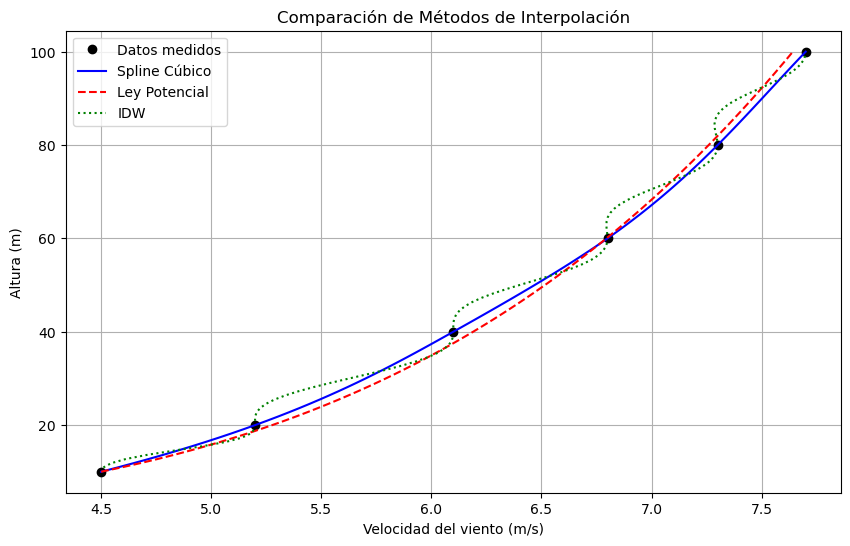

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

def fit_power_law(heights, velocities, h_ref):
    """
    Ajusta la ley potencial a los datos
    
    Parámetros:
    heights: array de alturas [m]
    velocities: array de velocidades [m/s]
    h_ref: altura de referencia [m]
    
    Retorna:
    alpha: exponente de cortante
    v_ref: velocidad de referencia
    """
    v_ref = velocities[np.where(heights == h_ref)[0][0]]
    # Ajuste por mínimos cuadrados en escala logarítmica
    y = np.log(velocities/v_ref)
    x = np.log(heights/h_ref)
    alpha = np.sum(x*y)/np.sum(x*x)
    return alpha, v_ref

def fit_cubic_spline(heights, velocities):
    """
    Ajusta un spline cúbico a los datos del perfil de viento
    
    Parámetros:
    heights: array de alturas [m]
    velocities: array de velocidades [m/s]
    
    Retorna:
    función de interpolación spline
    """
    cs = CubicSpline(heights, velocities)
    return cs

def idw_interpolation(heights, velocities, target_heights, p=2):
    """
    Interpolación ponderada por distancia inversa
    
    Parámetros:
    heights: alturas conocidas
    velocities: velocidades conocidas
    target_heights: alturas objetivo para interpolación
    p: potencia para ponderación (típicamente 2)
    
    Retorna:
    velocidades interpoladas
    """
    v_interp = np.zeros_like(target_heights)
    for i, h in enumerate(target_heights):
        weights = 1/np.abs(heights - h)**p
        v_interp[i] = np.sum(weights * velocities)/np.sum(weights)
    return v_interp

# Datos de ejemplo (alturas en metros, velocidades en m/s)
heights = np.array([10, 20, 40, 60, 80, 100])
velocities = np.array([4.5, 5.2, 6.1, 6.8, 7.3, 7.7])

# 1. Ajuste de Spline Cúbico
cs = CubicSpline(heights, velocities)
heights_fine = np.linspace(10, 100, 100)
velocities_spline = cs(heights_fine)

# 2. Ajuste de Ley Potencial
alpha, v_ref = fit_power_law(heights, velocities, 10)
velocities_power = v_ref * (heights_fine/10)**alpha

# 3. Interpolación IDW
velocities_idw = idw_interpolation(heights, velocities, heights_fine)

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(velocities, heights, 'ko', label='Datos medidos')
plt.plot(velocities_spline, heights_fine, 'b-', label='Spline Cúbico')
plt.plot(velocities_power, heights_fine, 'r--', label='Ley Potencial')
plt.plot(velocities_idw, heights_fine, 'g:', label='IDW')
plt.xlabel('Velocidad del viento (m/s)')
plt.ylabel('Altura (m)')
plt.title('Comparación de Métodos de Interpolación')
plt.legend()
plt.grid(True)
plt.show()

# Análisis de error en puntos de validación
validation_heights = np.array([30, 50, 70, 90])
# Aquí necesitarías datos reales de validación